#**Module 13 Assignment: Handwritten Digit Classifier (MNIST)**
#**Deep Learning Project using TensorFlow / Keras**
#**Student: Farjana Ferdausi**


# Introduction :

## This notebook builds a Deep Neural Network (DNN) to classify
## handwritten digits (0–9) from the MNIST dataset.

# Key techniques used :

##   • Data normalization & flattening
##   • Hidden layers with ReLU activation
##   • Batch Normalization for stable training
##   • Dropout regularization to reduce overfitting
##   • Softmax output layer for multi-class classification
##   • Training/validation accuracy & loss visualization

# STEP 1: Install & Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


# STEP 2 : Load the MNIST Dataset

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Dataset Loaded Successfully!
Training images shape : (60000, 28, 28)
Training labels shape : (60000,)
Test images shape     : (10000, 28, 28)
Test labels shape     : (10000,)
Pixel value range     : [0, 255]


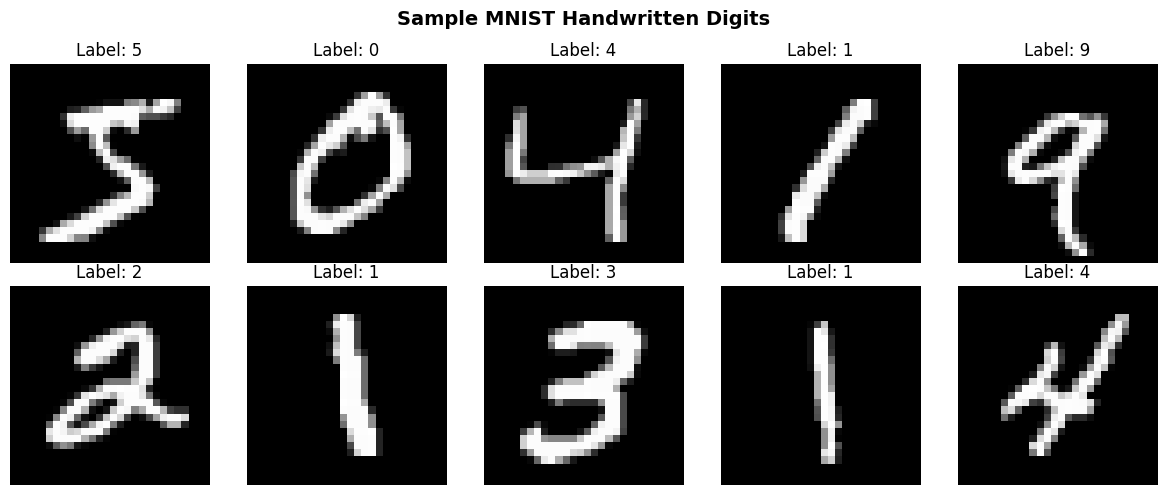

Sample digit plot saved.


In [2]:
# Load dataset directly from Keras
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"\nDataset Loaded Successfully!")
print(f"Training images shape : {x_train.shape}")   # (60000, 28, 28)
print(f"Training labels shape : {y_train.shape}")   # (60000,)
print(f"Test images shape     : {x_test.shape}")    # (10000, 28, 28)
print(f"Test labels shape     : {y_test.shape}")    # (10000,)
print(f"Pixel value range     : [{x_train.min()}, {x_train.max()}]")

# Visualize a few sample images from the dataset
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample MNIST Handwritten Digits", fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.tight_layout()
plt.savefig("sample_digits.png", dpi=150, bbox_inches='tight')
plt.show()
print("Sample digit plot saved.")


# STEP 3 : Data Preprocessing

In [3]:
# 3a. Normalize pixel values from [0, 255] → [0.0, 1.0]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

print(f"\nAfter Normalization:")
print(f"Pixel value range: [{x_train.min():.1f}, {x_train.max():.1f}]")

# 3b. Flatten each 28×28 image into a 784-dimensional vector
#     (required for Dense/fully-connected layers)
x_train_flat = x_train.reshape(-1, 28 * 28)   # shape: (60000, 784)
x_test_flat  = x_test.reshape(-1, 28 * 28)    # shape: (10000, 784)

print(f"\nAfter Flattening:")
print(f"x_train_flat shape: {x_train_flat.shape}")
print(f"x_test_flat  shape: {x_test_flat.shape}")

# 3c. One-hot encode the labels (e.g., 3 → [0,0,0,1,0,0,0,0,0,0])
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test,  num_classes=10)

print(f"\nAfter One-Hot Encoding:")
print(f"y_train_cat shape: {y_train_cat.shape}")
print(f"Example: label {y_train[0]} → {y_train_cat[0]}")


After Normalization:
Pixel value range: [0.0, 1.0]

After Flattening:
x_train_flat shape: (60000, 784)
x_test_flat  shape: (10000, 784)

After One-Hot Encoding:
y_train_cat shape: (60000, 10)
Example: label 5 → [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


# STEP 4 : Build the Deep Neural Network Model

In [4]:
# ────────────────────────────────────────────
# Build the Deep Neural Network Model
# ────────────────────────────────────────────
# Architecture:
#   Input (784)
#   → Dense(512) + BatchNorm + ReLU → Dropout(0.3)
#   → Dense(256) + BatchNorm + ReLU → Dropout(0.3)
#   → Dense(128) + BatchNorm + ReLU → Dropout(0.2)
#   → Dense(10, softmax)   ← Output layer
# ────────────────────────────────────────────────

def build_model(input_dim=784, num_classes=10):
    """
    Builds and returns a deep neural network for MNIST classification.

    Args:
        input_dim  : Number of input features (784 for flattened MNIST)
        num_classes: Number of output classes (10 digits)

    Returns:
        Compiled Keras model
    """
    model = keras.Sequential([

        # ── Hidden Layer 1 ──
        layers.Dense(512, input_shape=(input_dim,), name="dense_1"),
        layers.BatchNormalization(name="batchnorm_1"),   # Normalize activations
        layers.Activation("relu", name="relu_1"),
        layers.Dropout(0.3, name="dropout_1"),           # Drop 30% of neurons

        # ── Hidden Layer 2 ──
        layers.Dense(256, name="dense_2"),
        layers.BatchNormalization(name="batchnorm_2"),
        layers.Activation("relu", name="relu_2"),
        layers.Dropout(0.3, name="dropout_2"),           # Drop 30% of neurons

        # ── Hidden Layer 3 ──
        layers.Dense(128, name="dense_3"),
        layers.BatchNormalization(name="batchnorm_3"),
        layers.Activation("relu", name="relu_3"),
        layers.Dropout(0.2, name="dropout_3"),           # Drop 20% of neurons

        # ── Output Layer ──
        layers.Dense(num_classes, activation="softmax", name="output"),
        # Softmax converts raw scores → class probabilities
    ], name="MNIST_DNN")

    return model

# Build the model
model = build_model()

# Display architecture summary
model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "MNIST_DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_1                     │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_2                     │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_3                     │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571,018 (2.18 MB)

 Trainable params: 569,226 (2.17 MB)

 Non-trainable params: 1,792 (7.00 KB)

# STEP 5 : Compile the Model

In [5]:
# Compile the Model

model.compile(
    optimizer="adam",                        # Adaptive learning rate optimizer
    loss="categorical_crossentropy",         # Multi-class classification loss
    metrics=["accuracy"]                     # Track accuracy during training
)

print("\nModel compiled successfully!")
print(f"  Optimizer : Adam")
print(f"  Loss      : Categorical Crossentropy")
print(f"  Metrics   : Accuracy")


Model compiled successfully!
  Optimizer : Adam
  Loss      : Categorical Crossentropy
  Metrics   : Accuracy


# STEP 6 : Train the Model

In [6]:
# Train the Model

# Callbacks for better training
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,               # Stop if no improvement for 5 epochs
    restore_best_weights=True # Revert to best model weights
)

lr_reduce = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,               # Halve the learning rate
    patience=3,               # After 3 stagnant epochs
    min_lr=1e-6,
    verbose=1
)

print("\nStarting Training...\n")

history = model.fit(
    x_train_flat, y_train_cat,
    epochs=20,                # Maximum number of training epochs
    batch_size=128,           # Number of samples per gradient update
    validation_split=0.15,   # 15% of training data used for validation
    callbacks=[early_stop, lr_reduce],
    verbose=1                 # Show progress bar
)

print("\nTraining complete!")
print(f"Total epochs trained: {len(history.history['accuracy'])}")


Starting Training...

Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8974 - loss: 0.3496 - val_accuracy: 0.9631 - val_loss: 0.1260 - learning_rate: 0.0010
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9530 - loss: 0.1584 - val_accuracy: 0.9728 - val_loss: 0.0873 - learning_rate: 0.0010
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9630 - loss: 0.1216 - val_accuracy: 0.9771 - val_loss: 0.0767 - learning_rate: 0.0010
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9704 - loss: 0.0965 - val_accuracy: 0.9789 - val_loss: 0.0709 - learning_rate: 0.0010
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9737 - loss: 0.0833 - val_accuracy: 0.9790 - val_loss: 0.0722 - learning_rate: 0.0010
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9772 - loss: 0.0736 - val_accuracy: 0.9783 - val_loss: 0.0728 - learning_rate: 0.0010
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy:

# STEP 7 : Visualize Training History

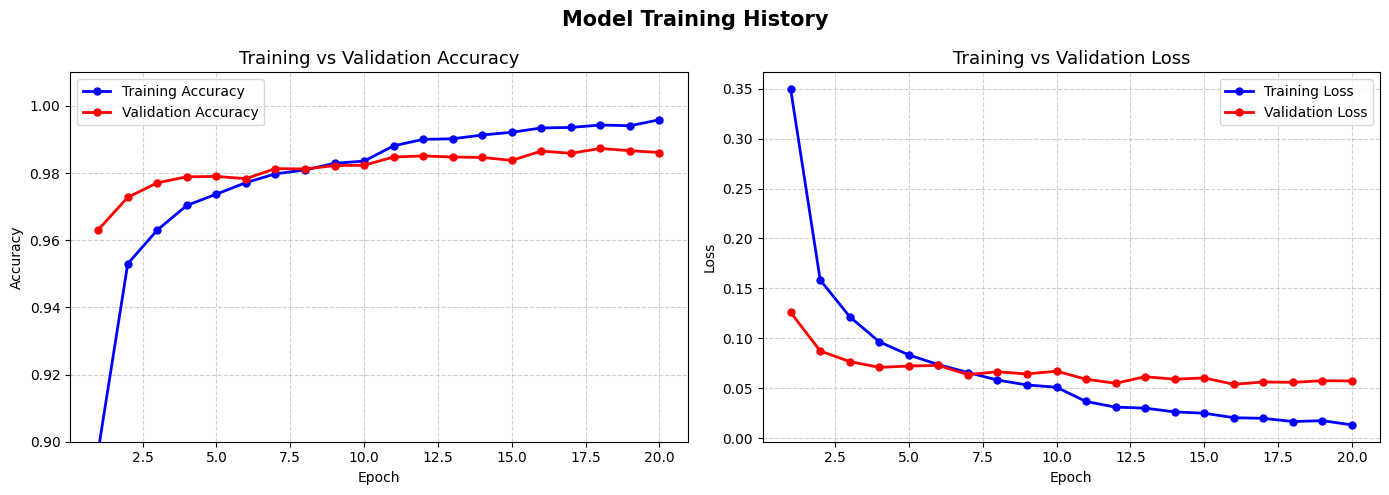

Training history plot saved.


In [7]:
# Visualize Training History

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Training History", fontsize=15, fontweight='bold')

epochs_ran = range(1, len(history.history['accuracy']) + 1)

# ── Plot 1: Accuracy ──
axes[0].plot(epochs_ran, history.history['accuracy'],
             'b-o', linewidth=2, markersize=5, label='Training Accuracy')
axes[0].plot(epochs_ran, history.history['val_accuracy'],
             'r-o', linewidth=2, markersize=5, label='Validation Accuracy')
axes[0].set_title('Training vs Validation Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_ylim([0.9, 1.01])

# ── Plot 2: Loss ───
axes[1].plot(epochs_ran, history.history['loss'],
             'b-o', linewidth=2, markersize=5, label='Training Loss')
axes[1].plot(epochs_ran, history.history['val_loss'],
             'r-o', linewidth=2, markersize=5, label='Validation Loss')
axes[1].set_title('Training vs Validation Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches='tight')
plt.show()
print("Training history plot saved.")

# STEP 8 : Evaluate on Test Set

In [8]:
# Evaluate on Test Set

test_loss, test_accuracy = model.evaluate(x_test_flat, y_test_cat, verbose=0)

print(f"\n{'='*45}")
print(f"  FINAL MODEL EVALUATION ON TEST SET")
print(f"{'='*45}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"{'='*45}")


  FINAL MODEL EVALUATION ON TEST SET
  Test Loss     : 0.0525
  Test Accuracy : 98.47%


# STEP 9 : Predictions & Confusion Analysis

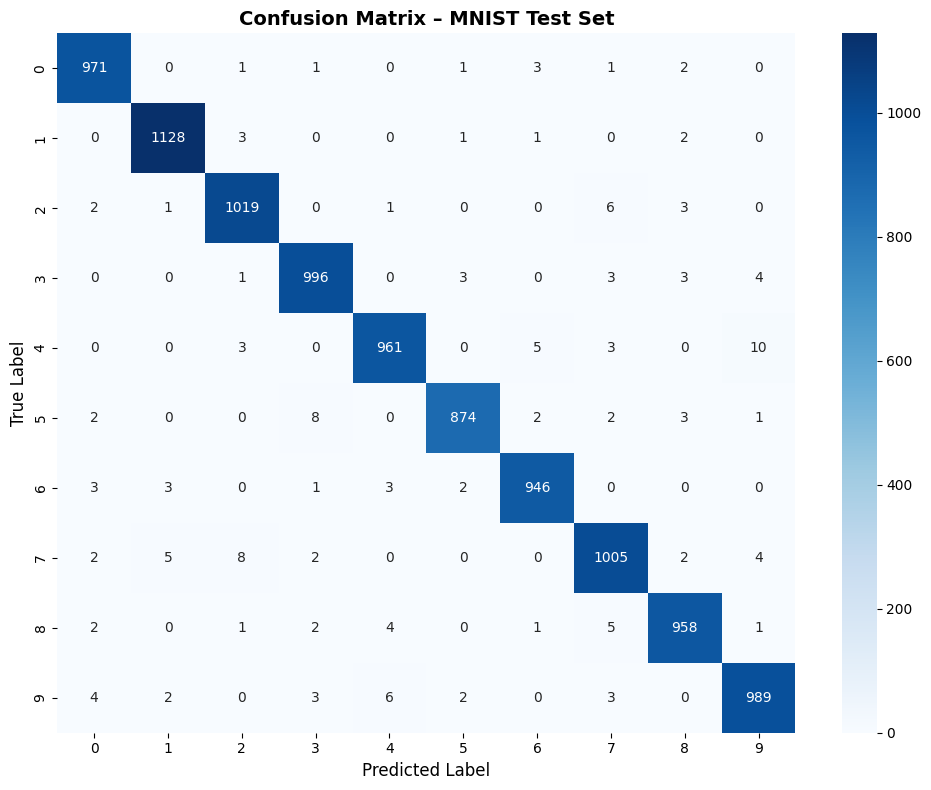

Confusion matrix saved.

Classification Report (per digit):
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.98      0.99      0.98      1010
           4       0.99      0.98      0.98       982
           5       0.99      0.98      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [9]:
# Predictions & Confusion Analysis

# Get class predictions for the test
y_pred_probs  = model.predict(x_test_flat, verbose=0)
y_pred_labels = np.argmax(y_pred_probs, axis=1)   # Predicted class indices
y_true_labels = np.argmax(y_test_cat, axis=1)      # True class indices

# ── Confusion Matrix ──
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix – MNIST Test Set', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved.")

# ── Classification Report ──
print("\nClassification Report (per digit):")
print(classification_report(y_true_labels, y_pred_labels,
                             target_names=[str(i) for i in range(10)]))


# STEP 10 : Visualize Sample Predictions

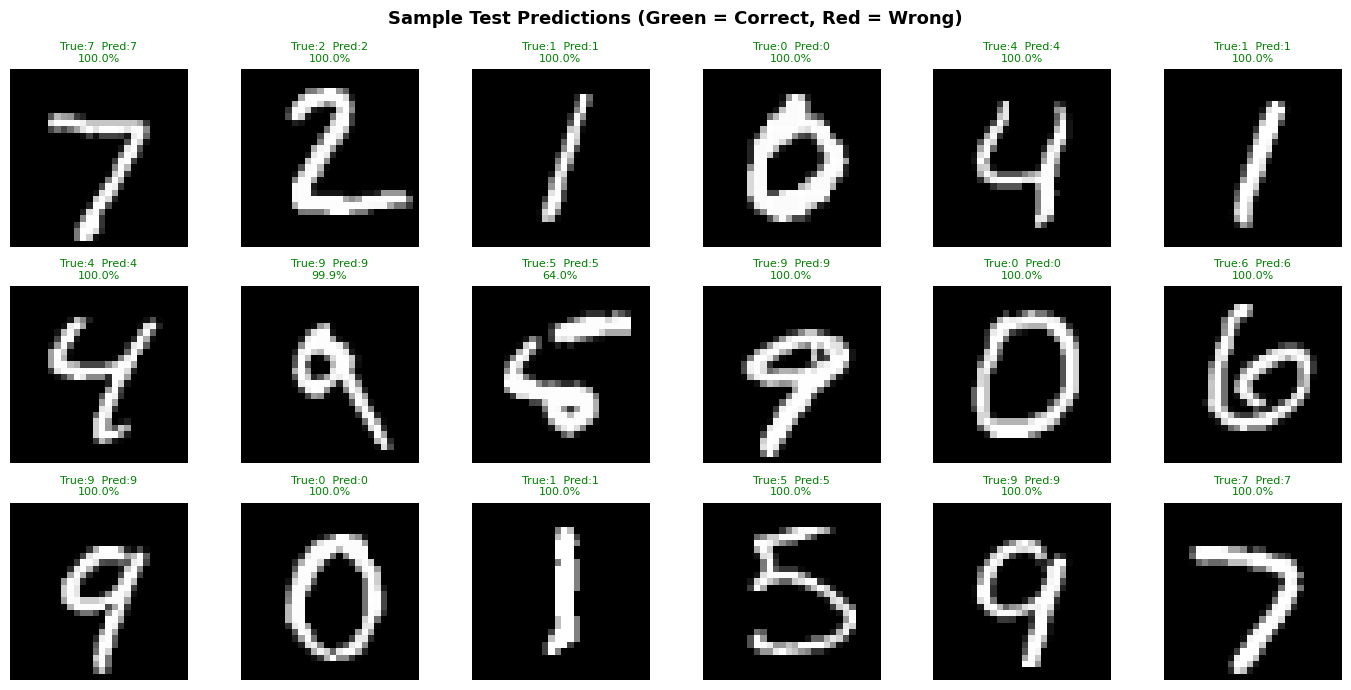

Sample predictions plot saved.


In [10]:
# Visualize Sample Predictions


fig, axes = plt.subplots(3, 6, figsize=(14, 7))
fig.suptitle("Sample Test Predictions (Green = Correct, Red = Wrong)",
             fontsize=13, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    image = x_test[idx].reshape(28, 28)
    true_label = y_true_labels[idx]
    pred_label = y_pred_labels[idx]
    confidence = y_pred_probs[idx][pred_label] * 100

    ax.imshow(image, cmap='gray')
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"True:{true_label}  Pred:{pred_label}\n{confidence:.1f}%",
                 color=color, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Sample predictions plot saved.")

# STEP 11 : Summary

In [11]:
# Summary

print("\n" + "="*50)
print("  PROJECT SUMMARY")
print("="*50)
print(f"  Dataset          : MNIST (60K train / 10K test)")
print(f"  Model Type       : Deep Neural Network (DNN)")
print(f"  Hidden Layers    : 3 (512 → 256 → 128 units)")
print(f"  Regularization   : BatchNorm + Dropout")
print(f"  Optimizer        : Adam")
print(f"  Loss Function    : Categorical Crossentropy")
print(f"  Epochs Trained   : {len(history.history['accuracy'])}")
print(f"  Test Accuracy    : {test_accuracy * 100:.2f}%")
print("="*50)
print("\n🟢 All steps completed successfully!")


  PROJECT SUMMARY
  Dataset          : MNIST (60K train / 10K test)
  Model Type       : Deep Neural Network (DNN)
  Hidden Layers    : 3 (512 → 256 → 128 units)
  Regularization   : BatchNorm + Dropout
  Optimizer        : Adam
  Loss Function    : Categorical Crossentropy
  Epochs Trained   : 20
  Test Accuracy    : 98.47%

🟢 All steps completed successfully!
